Using device: cuda

Running Baseline...

Starting PPO Training...
Iteration 0, Avg Fleet Reward: 1203.80
Iteration 10, Avg Fleet Reward: 4055.00
Iteration 20, Avg Fleet Reward: 5048.60
Iteration 30, Avg Fleet Reward: 10203.10
Iteration 40, Avg Fleet Reward: 9988.80
Iteration 50, Avg Fleet Reward: 10517.40
Iteration 60, Avg Fleet Reward: 10178.60
Iteration 70, Avg Fleet Reward: 10577.50
Iteration 80, Avg Fleet Reward: 11357.20
Iteration 90, Avg Fleet Reward: 8598.10
Iteration 100, Avg Fleet Reward: 9061.30
Iteration 110, Avg Fleet Reward: 11311.60
Iteration 120, Avg Fleet Reward: 10198.00
Iteration 130, Avg Fleet Reward: 10534.80
Iteration 140, Avg Fleet Reward: 10709.00
Iteration 150, Avg Fleet Reward: 10655.50
Iteration 160, Avg Fleet Reward: 11094.60
Iteration 170, Avg Fleet Reward: 11308.90
Iteration 180, Avg Fleet Reward: 11387.40
Iteration 190, Avg Fleet Reward: 11175.90
Iteration 200, Avg Fleet Reward: 10549.70
Iteration 210, Avg Fleet Reward: 11186.10
Iteration 220, Avg Fleet Re

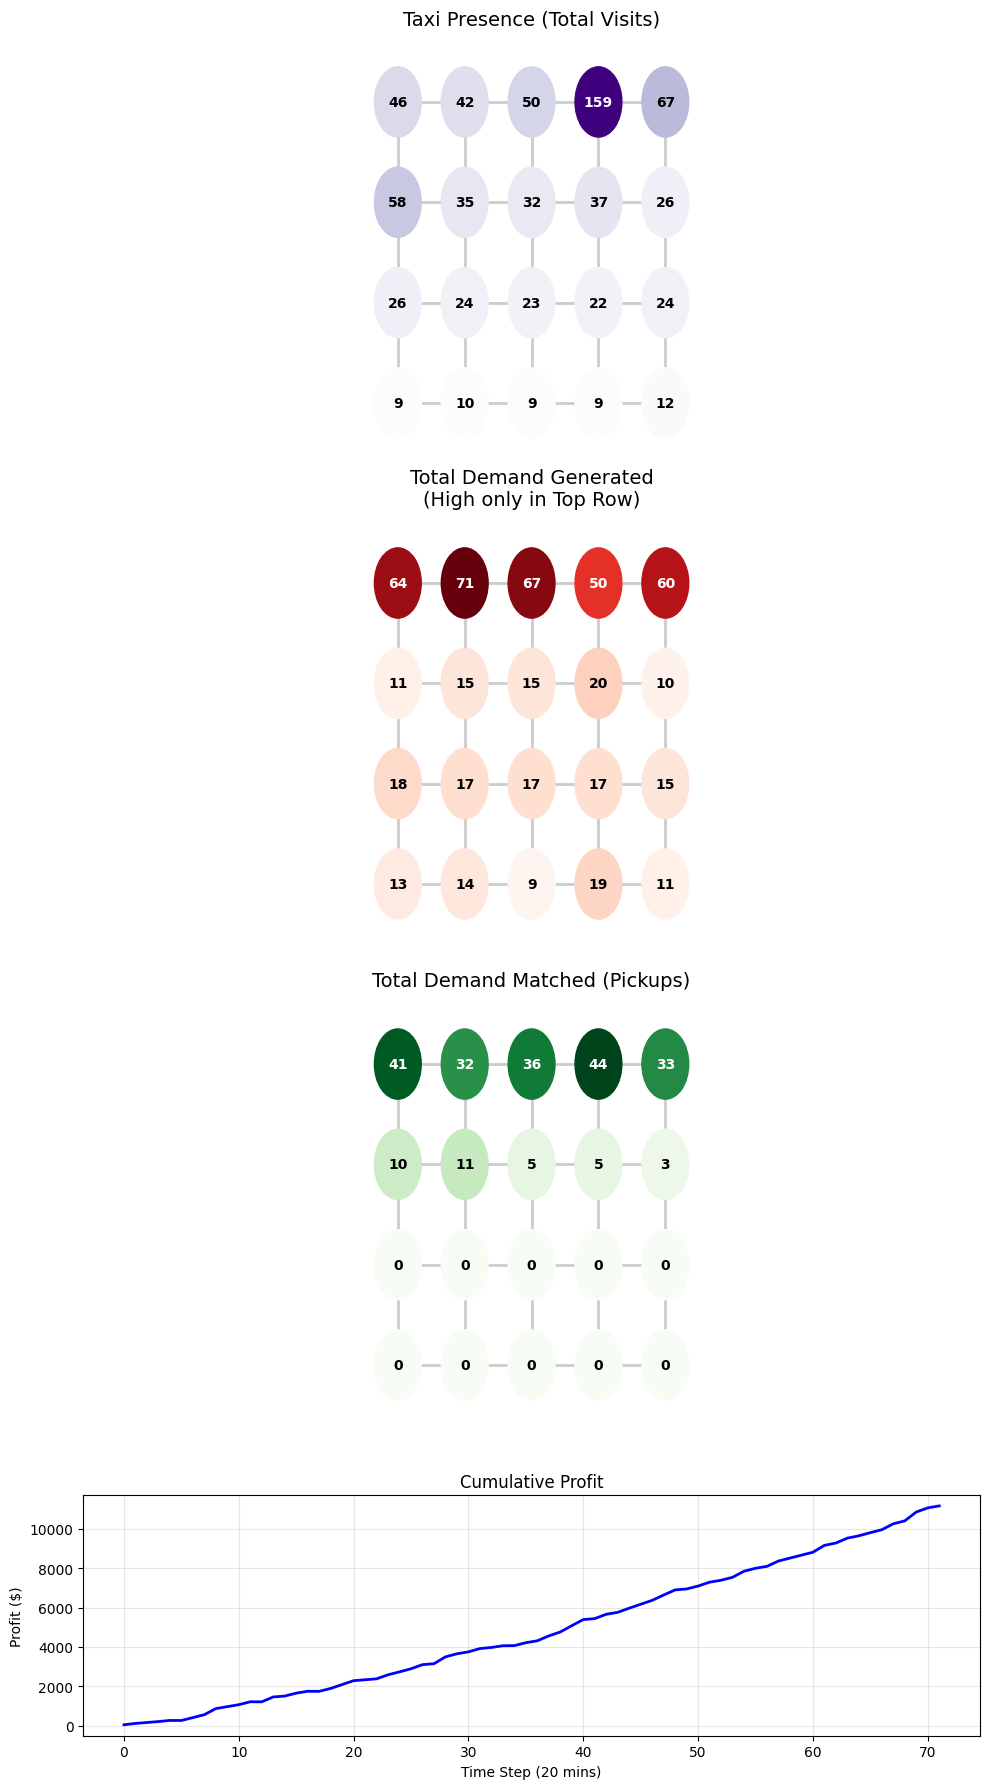

In [9]:
import gym
from gym import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---------------------------------------------------------
# 0. Device Setup
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------
# 1. Custom City Environment (Multi-Agent)
# ---------------------------------------------------------

class CityTaxiEnv(gym.Env):
    """
    A 4x5 Grid City Environment for Taxi Service (100 Cars).

    Layout:
    Row 0: [0, 1, 2, 3, 4]  <-- High Demand Zone
    Row 1: [5, 6, 7, 8, 9]
    Row 2: [10, 11, 12, 13, 14]
    Row 3: [15, 16, 17, 18, 19]

    Rewards:
    - Node 4 (Top-Right): 100.0 (10x)
    - Nodes 0-3 (Rest of Row 0): 50.0 (5x)
    - Nodes 5-19 (Others): 10.0 (1x)
    """

    def __init__(self, num_taxis=100):
        super(CityTaxiEnv, self).__init__()

        self.rows = 4
        self.cols = 5
        self.num_nodes = self.rows * self.cols
        self.num_taxis = num_taxis

        # Action space: 0=Pickup, 1-4=Move
        self.action_space = spaces.Discrete(5)

        # Observation: My Position (1) + Demand Map (20)
        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(1 + self.num_nodes,),
            dtype=np.float32
        )

        self.max_steps = 72 # 24 hours / 20 min steps
        self.current_step = 0
        self.taxi_locs = np.zeros(self.num_taxis, dtype=int)
        self.demand = np.zeros(self.num_nodes)

    def _get_coords(self, node):
        return node // self.cols, node % self.cols

    def _get_node(self, r, c):
        return r * self.cols + c

    def _generate_demand(self):
        """Generates Poisson demand for the step."""
        demand = np.zeros(self.num_nodes)

        # --- MODIFIED DEMAND ZONES ---
        # Highest Row (Nodes 0-4): High Demand
        for i in range(5):
            demand[i] = np.random.poisson(lam=0.8)

        # All other rows (Nodes 5-19): Low Demand
        for i in range(5, 20):
            demand[i] = np.random.poisson(lam=0.2)
        # -----------------------------
        return demand

    def _get_observation_batch(self):
        locs = self.taxi_locs.reshape(-1, 1)
        demands = np.tile(self.demand, (self.num_taxis, 1))
        return np.concatenate((locs, demands), axis=1).astype(np.float32)

    def reset(self):
        self.current_step = 0
        self.taxi_locs = np.random.randint(0, self.num_nodes, size=self.num_taxis)
        self.demand = self._generate_demand()
        return self._get_observation_batch()

    def step(self, actions):
        rewards = np.zeros(self.num_taxis)
        done = False
        picked_up_map = np.zeros(self.num_nodes)

        for i in range(self.num_taxis):
            action = actions[i]
            loc = self.taxi_locs[i]
            r, c = self._get_coords(loc)

            if action == 0: # PICK UP
                if self.demand[loc] > 0:

                    # --- MODIFIED REWARD STRUCTURE ---
                    if loc == 4:
                        # Top-Right Node (Super Bonus)
                        rewards[i] = 100.0
                    elif loc < 5:
                        # Rest of Highest Row (Nodes 0,1,2,3)
                        rewards[i] = 50.0
                    else:
                        # Standard Zone
                        rewards[i] = 10.0
                    # ---------------------------------

                    self.demand[loc] -= 1
                    picked_up_map[loc] += 1
                    self.taxi_locs[i] = np.random.randint(0, self.num_nodes)
                else:
                    rewards[i] = -1.0

            else: # MOVE
                new_r, new_c = r, c
                if action == 1: new_r -= 1
                elif action == 2: new_r += 1
                elif action == 3: new_c -= 1
                elif action == 4: new_c += 1

                if 0 <= new_r < self.rows and 0 <= new_c < self.cols:
                    self.taxi_locs[i] = self._get_node(new_r, new_c)
                else:
                    rewards[i] = -0.5

        new_demand = self._generate_demand()
        self.demand += new_demand
        self.demand = np.clip(self.demand, 0, 50)

        self.current_step += 1
        if self.current_step >= self.max_steps:
            done = True

        next_obs = self._get_observation_batch()
        info = {'generated_demand': new_demand, 'picked_up_map': picked_up_map}
        return next_obs, rewards, done, info

# ---------------------------------------------------------
# 2. PPO Classes
# ---------------------------------------------------------

class Policy(object):
    def __init__(self, obssize, actsize, lr, device):
        self.device = device
        self.actsize = actsize
        self.model = torch.nn.Sequential(
            torch.nn.Linear(obssize, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, actsize)
        ).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def compute_prob(self, states):
        states = torch.FloatTensor(states).to(self.device)
        logits = self.model(states)
        prob = torch.nn.functional.softmax(logits, dim=-1)
        return prob.cpu().data.numpy()

    def _to_one_hot(self, y, num_classes):
        scatter_dim = len(y.size())
        y_tensor = y.view(*y.size(), -1)
        zeros = torch.zeros(*y.size(), num_classes, dtype=y.dtype, device=self.device)
        return zeros.scatter(scatter_dim, y_tensor, 1)

    def train(self, states, actions, Qs):
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        Qs = torch.FloatTensor(Qs).to(self.device)

        logits = self.model(states)
        prob = torch.nn.functional.softmax(logits, dim=-1)
        action_onehot = self._to_one_hot(actions, self.actsize)
        prob_selected = torch.sum(prob * action_onehot, axis=-1) + 1e-8
        log_prob_selected = torch.log(prob_selected)
        loss = -torch.mean(Qs * log_prob_selected)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.detach().cpu().data.numpy()

class ValueFunction(object):
    def __init__(self, obssize, lr, device):
        self.device = device
        self.model = torch.nn.Sequential(
            torch.nn.Linear(obssize, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1)
        ).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def compute_values(self, states):
        states = torch.FloatTensor(states).to(self.device)
        return self.model(states).cpu().data.numpy()

    def train(self, states, targets):
        states = torch.FloatTensor(states).to(self.device)
        targets = torch.FloatTensor(targets).to(self.device)
        v_preds = self.model(states)
        loss = torch.nn.functional.mse_loss(v_preds, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.detach().cpu().data.numpy()

def discounted_rewards(r, gamma):
    discounted_r = np.zeros_like(r, dtype=np.float32)
    running_sum = 0
    for i in reversed(range(0, len(r))):
        discounted_r[i] = running_sum * gamma + r[i]
        running_sum = discounted_r[i]
    return list(discounted_r)

# ---------------------------------------------------------
# 3. Training & Visualization
# ---------------------------------------------------------

def evaluate(policy, env, episodes):
    total_score = 0
    for episode in range(episodes):
        obs_batch = env.reset()
        done = False
        episode_reward = 0
        while not done:
            p = policy.compute_prob(obs_batch)
            actions = []
            for i in range(env.num_taxis):
                p_i = p[i] / np.sum(p[i])
                act = np.random.choice(np.arange(env.action_space.n), p=p_i)
                actions.append(act)
            obs_batch, rewards, done, _ = env.step(actions)
            episode_reward += np.sum(rewards)
        total_score += episode_reward
    return total_score / episodes

def run_baseline(env, episodes=50):
    print(f"\nRunning Baseline...")
    total_score = 0
    for episode in range(episodes):
        obs_batch = env.reset()
        done = False
        episode_reward = 0
        while not done:
            actions = []
            current_demand_snapshot = env.demand.copy()
            for i in range(env.num_taxis):
                loc = env.taxi_locs[i]
                if current_demand_snapshot[loc] > 0:
                    action = 0 # Pickup
                    current_demand_snapshot[loc] -= 1
                else:
                    action = np.random.randint(1, 5)
                actions.append(action)
            obs_batch, rewards, done, _ = env.step(actions)
            episode_reward += np.sum(rewards)
        total_score += episode_reward
    return total_score / episodes

def visualize_last_day(policy, env):
    print("\nVisualizing last day (1 Episode)...")
    obs_batch = env.reset()
    done = False

    taxi_visits = np.zeros(env.num_nodes)
    demand_generated = np.zeros(env.num_nodes)
    demand_matched = np.zeros(env.num_nodes)
    cumulative_profit = []
    current_profit = 0

    while not done:
        for loc in env.taxi_locs:
            taxi_visits[loc] += 1

        p = policy.compute_prob(obs_batch)
        actions = []
        for i in range(env.num_taxis):
            p_i = p[i] / np.sum(p[i])
            act = np.random.choice(np.arange(env.action_space.n), p=p_i)
            actions.append(act)

        obs_batch, rewards, done, info = env.step(actions)

        current_profit += np.sum(rewards)
        cumulative_profit.append(current_profit)
        demand_generated += info['generated_demand']
        demand_matched += info['picked_up_map']

    # --- VISUALIZATION LOGIC ---
    fig = plt.figure(figsize=(10, 18))
    gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 0.6])

    def plot_grid_graph(ax, data, title, cmap='Blues'):
        """Plots a graph representation with nodes and edges."""
        rows, cols = env.rows, env.cols

        # Color mapping
        norm = plt.Normalize(vmin=data.min(), vmax=data.max())
        m = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

        # 1. Draw Edges (Grid structure)
        for r in range(rows):
            for c in range(cols):
                # Horizontal
                if c < cols - 1:
                    ax.plot([c, c+1], [-r, -r], color='#CCCCCC', linewidth=2, zorder=1)
                # Vertical
                if r < rows - 1:
                    ax.plot([c, c], [-r, -r-1], color='#CCCCCC', linewidth=2, zorder=1)

        # 2. Draw Nodes (Circles)
        for r in range(rows):
            for c in range(cols):
                val = data[r, c]
                color = m.to_rgba(val)
                circle = patches.Circle((c, -r), 0.35, color=color, zorder=2)
                ax.add_patch(circle)

                # Contrast check for text
                brightness = (0.299*color[0] + 0.587*color[1] + 0.114*color[2])
                text_color = 'white' if brightness < 0.5 else 'black'

                ax.text(c, -r, f"{int(val)}",
                        ha='center', va='center',
                        color=text_color, fontweight='bold', fontsize=10, zorder=3)

        ax.set_title(title, fontsize=14, pad=20)
        ax.set_xlim(-0.5, cols-0.5)
        ax.set_ylim(-rows+0.5, 0.5)
        ax.axis('off')
        ax.set_aspect(1.5)

    # Reshape data
    visit_grid = taxi_visits.reshape(env.rows, env.cols)
    gen_grid = demand_generated.reshape(env.rows, env.cols)
    match_grid = demand_matched.reshape(env.rows, env.cols)

    # Plot Graphs
    ax1 = fig.add_subplot(gs[0])
    plot_grid_graph(ax1, visit_grid, "Taxi Presence (Total Visits)", cmap='Purples')

    ax2 = fig.add_subplot(gs[1])
    plot_grid_graph(ax2, gen_grid, "Total Demand Generated\n(High only in Top Row)", cmap='Reds')

    ax3 = fig.add_subplot(gs[2])
    plot_grid_graph(ax3, match_grid, "Total Demand Matched (Pickups)", cmap='Greens')

    # Plot Profit Curve
    ax4 = fig.add_subplot(gs[3])
    ax4.plot(cumulative_profit, color='blue', linewidth=2)
    ax4.set_title("Cumulative Profit", fontsize=12)
    ax4.set_xlabel("Time Step (20 mins)")
    ax4.set_ylabel("Profit ($)")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    alpha = 1e-3
    beta = 1e-3
    numtrajs = 5
    iterations = 500
    gamma = 0.997
    num_taxis = 10

    env = CityTaxiEnv(num_taxis=num_taxis)
    obssize = env.observation_space.shape[0]
    actsize = env.action_space.n

    # --- CALCULATE BASELINE ---
    baseline_score = run_baseline(env, episodes=50)

    actor = Policy(obssize, actsize, alpha, device)
    baseline = ValueFunction(obssize, beta, device)

    print("\nStarting PPO Training...")

    for ite in range(iterations):
        OBS_BUFFER = []
        ACTS_BUFFER = []
        VAL_BUFFER = []
        total_batch_reward = 0

        for num in range(numtrajs):
            car_obss = [[] for _ in range(num_taxis)]
            car_acts = [[] for _ in range(num_taxis)]
            car_rews = [[] for _ in range(num_taxis)]
            obs_batch = env.reset()
            done = False

            while not done:
                for i in range(num_taxis):
                    car_obss[i].append(obs_batch[i])
                probs = actor.compute_prob(obs_batch)
                actions = []
                for i in range(num_taxis):
                    a = np.random.choice(actsize, p=probs[i].flatten())
                    actions.append(a)
                    car_acts[i].append(a)
                next_obs_batch, rewards, done, _ = env.step(actions)
                for i in range(num_taxis):
                    car_rews[i].append(rewards[i])
                obs_batch = next_obs_batch

            ep_total = 0
            for i in range(num_taxis):
                ep_total += np.sum(car_rews[i])
                dis_r = discounted_rewards(car_rews[i], gamma)
                OBS_BUFFER.extend(car_obss[i])
                ACTS_BUFFER.extend(car_acts[i])
                VAL_BUFFER.extend(dis_r)
            total_batch_reward += ep_total

        if ite % 10 == 0:
            print(f"Iteration {ite}, Avg Fleet Reward: {total_batch_reward / numtrajs:.2f}")

        obs_train = np.array(OBS_BUFFER)
        val_train = np.array(VAL_BUFFER)
        acts_train = np.array(ACTS_BUFFER)

        baseline.train(obs_train, val_train)
        v_preds = baseline.compute_values(obs_train).flatten()
        advantages = val_train - v_preds
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / advantages.std()
        actor.train(obs_train, acts_train, advantages)

    # --- EVALUATE AND COMPARE ---
    print("\nTraining Complete. Evaluating PPO...")
    test_score = evaluate(actor, env, episodes=50)

    print("-" * 30)
    print(f"Baseline Score:       {baseline_score:.2f}")
    print(f"Final PPO Test Score: {test_score:.2f}")
    print("-" * 30)

    if test_score > baseline_score:
        print("Result: PPO outperformed the Baseline!")
    else:
        print("Result: PPO failed to beat the Baseline.")

    visualize_last_day(actor, env)

if __name__ == "__main__":
    main()